In [ ]:
---
title: "Data Exploration and Visaulization"
---

---
title: "Data Exploration and Visualization"
---

In [8]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [9]:
lobsterland = pd.read_csv('lobster_25.csv')

In [10]:
# A.
lobsterland.head()

,Date,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,...,Weather_Type,Weather_Code,Promo_Flag,Promo_Type,Cruise_Docked,Is_Special_Event,Special_Events,Attraction_Tier,Zone_ID,Per_Capita_Spend
0,2025-05-26,Monday,1,1,1769,48.65,908,77.42,70297.36,40521.91,...,Thunderstorms,4,0,NaN,0,0,NaN,2,101,73.43
1,2025-05-27,Tuesday,1,0,1717,60.58,677,69.80,47254.60,35298.92,...,Partly Cloudy,2,0,NaN,0,0,NaN,2,101,59.30
2,2025-05-28,Wednesday,1,0,1600,30.84,1107,70.09,77589.63,36495.95,...,Partly Cloudy,2,0,NaN,0,0,NaN,3,103,82.33
3,2025-05-29,Thursday,1,0,1037,19.02,840,72.30,60732.00,22486.65,...,Showers,3,0,NaN,0,0,NaN,2,101,91.19
4,2025-05-30,Friday,1,0,1671,66.18,565,68.11,38482.15,40705.15,...,Partly Cloudy,2,0,NaN,0,0,NaN,1,104,58.67


B.
There are 5 rows showing.

In [11]:
# C.
lobsterland.shape

(99, 27)

There are **99 rows** and **27 columns**

In [12]:
# D.
lobsterland.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    99 non-null     object 
 1   Day_of_Week             99 non-null     object 
 2   season_week_rel         99 non-null     int64  
 3   Is_Holiday              99 non-null     int64  
 4   Total_Visitors          99 non-null     int64  
 5   Passholder_Percentage   99 non-null     float64
 6   Day_Tickets_Sold        99 non-null     int64  
 7   Avg_Ticket_Price        99 non-null     float64
 8   Gate_Revenue            99 non-null     float64
 9   Revenue_Food            99 non-null     float64
 10  Revenue_Merch           94 non-null     float64
 11  Revenue_Arcade          99 non-null     float64
 12  Total_Revenue           99 non-null     float64
 13  Total_Labor_Hours       99 non-null     float64
 14  International_Visitors  94 non-null     floa

**Numeric**: Total Vistors, Passholder Percentage, Tickets Sold per Day, Average Ticket Price, Gate Revenue, Revenue from Food, Revenue from Merch, Revenue from Arcade, Total Revenue, Total Labor Hours, International Vistors, High Temperature, Per Capita Spend
**Categorical**: Date, Day of Week, Season Week, Holiday, Precipitation, Weather Type, Weather Code, Promo Flag, Cruise Docked, Special Event, Attraction Tier, Zone ID

In [13]:
#E.
lobsterland.isnull().sum()

,0
Date,0
Day_of_Week,0
season_week_rel,0
Is_Holiday,0
Total_Visitors,0
Passholder_Percentage,0
Day_Tickets_Sold,0
Avg_Ticket_Price,0
Gate_Revenue,0
Revenue_Food,0


Merchandise Revenue, International Visitors, Promotion type and Special Events all have missing values. Both Promotion Type and Special Events can be filled with 'None' to show that their is either no Promotion or Special Event occuring. By filling it with a 'None' it completes the data.

In [14]:
lobsterland['Promo_Type']=lobsterland['Promo_Type'].fillna('None')

In [15]:
lobsterland['Special_Events']=lobsterland['Special_Events'].fillna('None')

In [16]:
lobsterland.isnull().sum()

,0
Date,0
Day_of_Week,0
season_week_rel,0
Is_Holiday,0
Total_Visitors,0
Passholder_Percentage,0
Day_Tickets_Sold,0
Avg_Ticket_Price,0
Gate_Revenue,0
Revenue_Food,0


In [17]:
lobsterland.groupby('Day_of_Week').International_Visitors.mean()

,International_Visitors
Day_of_Week,
Friday,165.307692
Monday,179.928571
Saturday,199.000000
Sunday,246.000000
Thursday,142.692308
Tuesday,175.500000
Wednesday,155.923077


In [18]:
lobsterland['International_Visitors'] = lobsterland.groupby('Day_of_Week')['International_Visitors'].transform(lambda x: x.fillna(x.mean()))

In [19]:
lobsterland.groupby('Day_of_Week').Revenue_Merch.mean()

,Revenue_Merch
Day_of_Week,
Friday,16711.526923
Monday,14809.618000
Saturday,28601.390000
Sunday,29654.362308
Thursday,14164.384615
Tuesday,13811.780769
Wednesday,14001.851538


In [20]:
lobsterland['Revenue_Merch'] = lobsterland.groupby('Day_of_Week')['Revenue_Merch'].transform(lambda x: x.fillna(x.mean()))

I used the mean values to per day of the week to be inserted into the missing values for both the international visitors and the revenue merch as the days of the week showed clear trends of what we would have expected to have seen on that day. The number of international visitors and revenue merch varied throughout the dataset depending on the day of the week, therefore I decided this was the best method to complete the data with some justification and relative accuracy.

In [21]:
# F.
lobsterland.rename(columns = {'Revenue_Food': 'FoodBev_Rev'}, inplace = True)
lobsterland.head()

,Date,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,FoodBev_Rev,...,Weather_Type,Weather_Code,Promo_Flag,Promo_Type,Cruise_Docked,Is_Special_Event,Special_Events,Attraction_Tier,Zone_ID,Per_Capita_Spend
0,2025-05-26,Monday,1,1,1769,48.65,908,77.42,70297.36,40521.91,...,Thunderstorms,4,0,None,0,0,None,2,101,73.43
1,2025-05-27,Tuesday,1,0,1717,60.58,677,69.80,47254.60,35298.92,...,Partly Cloudy,2,0,None,0,0,None,2,101,59.30
2,2025-05-28,Wednesday,1,0,1600,30.84,1107,70.09,77589.63,36495.95,...,Partly Cloudy,2,0,None,0,0,None,3,103,82.33
3,2025-05-29,Thursday,1,0,1037,19.02,840,72.30,60732.00,22486.65,...,Showers,3,0,None,0,0,None,2,101,91.19
4,2025-05-30,Friday,1,0,1671,66.18,565,68.11,38482.15,40705.15,...,Partly Cloudy,2,0,None,0,0,None,1,104,58.67


In [22]:
# G.
revenue_by_event = lobsterland[lobsterland['Special_Events'] != 'None'].groupby('Special_Events')[['Gate_Revenue', 'FoodBev_Rev', 'Revenue_Merch', 'Revenue_Arcade']].sum()
revenue_by_event['Total'] = revenue_by_event[['Gate_Revenue', 'FoodBev_Rev', 'Revenue_Merch', 'Revenue_Arcade']].sum(axis=1)
display(revenue_by_event.style.format('${:,.2f}'))

,Gate_Revenue,FoodBev_Rev,Revenue_Merch,Revenue_Arcade,Total
Special_Events,,,,,
Beatles Tribute,"$439,892.61","$260,303.90","$93,947.44","$31,464.15","$825,608.10"
MusicFest,"$321,890.25","$250,634.14","$99,196.47","$29,237.73","$700,958.59"
Night Glow,"$323,872.98","$178,772.33","$95,191.13","$25,913.46","$623,749.90"
Taylor Swift Lookalike,"$290,686.01","$201,497.15","$100,437.23","$29,075.35","$621,695.74"
Vintage Days,"$342,715.23","$153,223.22","$73,685.93","$20,463.95","$590,088.33"


**Stand Out Features:** The table shows that the Gate Revenue and the Food/Beverage Revenue are significantly larger than the Merchandise and Arcade Revenue. Gate Revenue makes up close to 50% of the Total Revenue per Special Event. The Beatles Tribute Special Event was the highest performing event based total revenue for this data, earning 825,608, and the Vintage Days was the lowest performing based on total revenue for this data. The Beatles significantly outperfomed the other Special Events on Gate Revenue, earning over 100,000 then Music Fest (2nd highest total), whilst the Merchandise Revenue and Arcade Revenue were more comparable between all of the Events.

**Limitations:** The table does not provide the frequency of the events, changes in price for the respective revenue streams or days of the week the events occured on, therefore we cannot accurately compare the events without greater context. Our analysis through the table allows a broad, top level analysis of the special events revenues but does not give specific details to provide context of how they may differ. As mentioned, without knowing further details, we are limited in the accuracy of the conclusions we can make about each Special Events Performance.


In [23]:
# H.
lobsterland.Date.info()

<class 'pandas.core.series.Series'>
RangeIndex: 99 entries, 0 to 98
Series name: Date
Non-Null Count  Dtype 
--------------  ----- 
99 non-null     object
dtypes: object(1)
memory usage: 924.0+ bytes


Pandas currently see the Date as an **Object**

In [24]:
lobsterland['Date'] = pd.to_datetime(lobsterland['Date'])
lobsterland.Date.info()

<class 'pandas.core.series.Series'>
RangeIndex: 99 entries, 0 to 98
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
99 non-null     datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 924.0 bytes


Transforming the Date from an an Object to a **DateTime** variable is important for clean, easy to interpret visuals and graphs, when using Date as the variable. It is also easier as it allows us to perform numerical analysis of dates. For example, when showing trends over time, it helps make the graph easier to interpret, and can allow us to set a min or max value. Ultimately, it turns date as a label into a number with structure.

In [25]:
# I.
daily_revenue = lobsterland.groupby('Day_of_Week')['Total_Revenue'].mean().to_frame()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue = daily_revenue.reindex(day_order)
display(daily_revenue.style.format('${:,.2f}'))

,Total_Revenue
Day_of_Week,
Monday,"$123,881.24"
Tuesday,"$110,803.41"
Wednesday,"$111,780.54"
Thursday,"$110,808.97"
Friday,"$124,348.35"
Saturday,"$233,435.69"
Sunday,"$222,040.76"


There are 3 main groupings of total revenue per day of the week. The weekends (Sat, Sun) earn significantly more revenue than the week days, earning 233,435 and 222,040 on average, respectively. The middle of the week (Tues, Wed, Thurs) earn the lowest amount at approximately 110,000 on average. Monday and Friday earn slightly more at the beginning and end of the working each at 123,881 and 124,348 respectively.

The weekends are likely to earn the highest total revenue on average as people are not at work and or may be travelling to maine during this time period. Additionally, Monday and Friday may be higher than the middle of the week as people may choose to extend their weekend holidays to a long weekend, and therefore attend lobsterland immediately before or after the weekend, where it may be less busy, and remote work options are available. The middle of the week is the lowest as people are likely at work/school and it is not close to the weekend where people may have extended time or flexible remote-work options

In [26]:
# J.
lobsterland_2 = lobsterland.drop('Zone_ID', axis=1)

In [27]:
lobsterland_2.head()

,Date,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,FoodBev_Rev,...,Precipitation,Weather_Type,Weather_Code,Promo_Flag,Promo_Type,Cruise_Docked,Is_Special_Event,Special_Events,Attraction_Tier,Per_Capita_Spend
0,2025-05-26,Monday,1,1,1769,48.65,908,77.42,70297.36,40521.91,...,1,Thunderstorms,4,0,None,0,0,None,2,73.43
1,2025-05-27,Tuesday,1,0,1717,60.58,677,69.80,47254.60,35298.92,...,0,Partly Cloudy,2,0,None,0,0,None,2,59.30
2,2025-05-28,Wednesday,1,0,1600,30.84,1107,70.09,77589.63,36495.95,...,0,Partly Cloudy,2,0,None,0,0,None,3,82.33
3,2025-05-29,Thursday,1,0,1037,19.02,840,72.30,60732.00,22486.65,...,1,Showers,3,0,None,0,0,None,2,91.19
4,2025-05-30,Friday,1,0,1671,66.18,565,68.11,38482.15,40705.15,...,0,Partly Cloudy,2,0,None,0,0,None,1,58.67


In the head table above you can see that the Zone ID is no longer present.

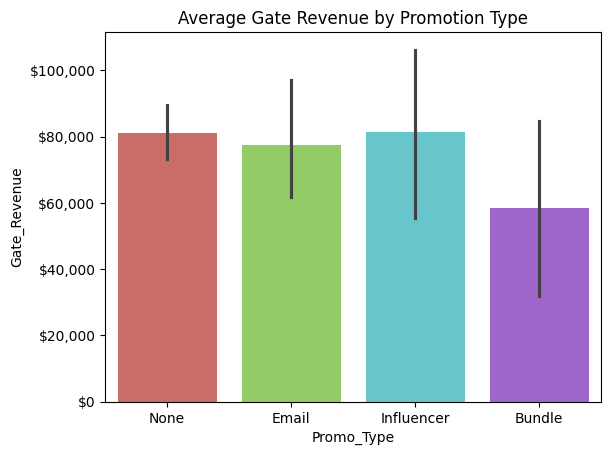

In [28]:
# K.
sns.barplot(x='Promo_Type', y='Gate_Revenue', data=lobsterland_2, hue='Promo_Type', palette='hls')
plt.title('Average Gate Revenue by Promotion Type')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.show()

We can see that having no promotion, using email, and using influencer promotion all generate a similar average gate revenue, around 80,000. Influencer slightly outperforms email and none as the highest average revenue, but the difference is minimal. The Bundle promotion type is the lowest one of them all, around 60,000. I am surpised that having no promotion generates a similar average gate revenue to email and influencer, and that the bundled promotion actually leads to less than just using one promotion type.

/tmp/ipython-input-3804276335.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([day[:3] for day in lobsterland_2['Day_of_Week'].unique()])


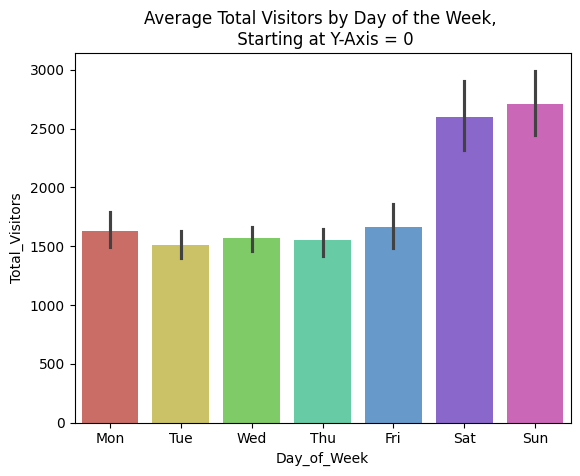

In [29]:
#L.
sns.barplot(x='Day_of_Week', y='Total_Visitors', data=lobsterland_2, hue='Day_of_Week',palette='hls')
plt.title('Average Total Visitors by Day of the Week, \n Starting at Y-Axis = 0')
plt.gca().set_xticklabels([day[:3] for day in lobsterland_2['Day_of_Week'].unique()])
plt.show()

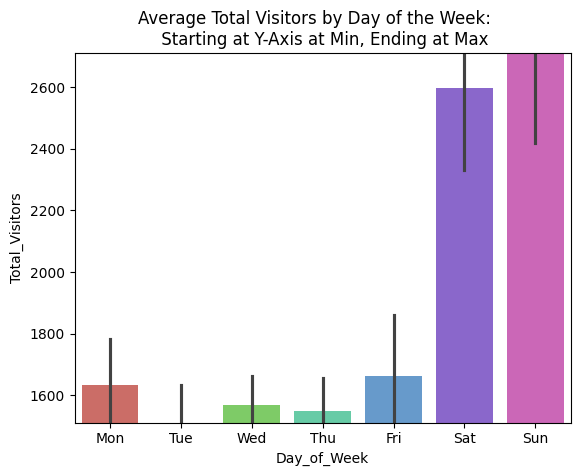

In [30]:


avg_visitors_per_day = lobsterland_2.groupby('Day_of_Week')['Total_Visitors'].mean()

ax = sns.barplot(x='Day_of_Week', y='Total_Visitors', data=lobsterland_2, hue='Day_of_Week', palette='hls', legend=False)
plt.title('Average Total Visitors by Day of the Week:   \n Starting at Y-Axis at Min, Ending at Max')
plt.ylim(avg_visitors_per_day.min(), avg_visitors_per_day.max())

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([day[:3] for day in lobsterland_2['Day_of_Week'].unique()], rotation=0)

plt.show()

Changing the axis range alters the interpretation of the differences across days as it does not allow for a even comparison between each day of the week. With Tuesday at the minimum and Sunday at the maximum, the perspective is that the difference between the two are significantly large. Whilst the other days of the week are also much smaller than the weekends, it makes them look bigger than Tuesday. However, in comparison for an appropriately scaled graph we can see that on an comparable scale that all the weekdays are very similar, and the weekends get approximately 1,000 more visitors on avaerage, but the magnitude of difference across the days is much more proportionate. This is incredibly important for responsible data communication as visual representations need to be easy to understand with clear, defined insights to be extracted. Proper scale and magnitude also demonstrate trends and outliers much clearer than a poorly scaled graph.

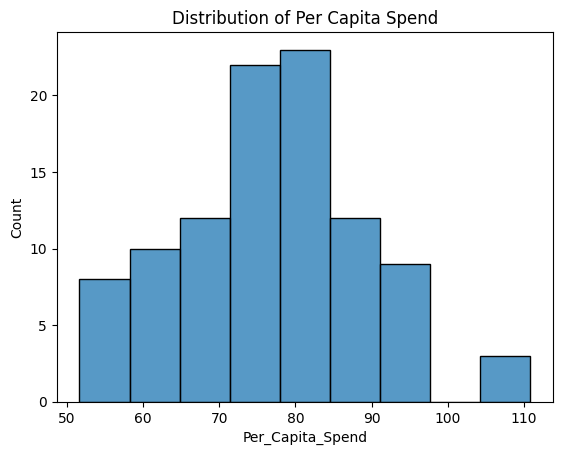

In [31]:
# M.
sns.histplot(x = 'Per_Capita_Spend', data = lobsterland_2)
plt.title('Distribution of Per Capita Spend')
plt.show()

The graph shows that the Per Capita Spend is normally distributed, with the average spend per person being approximately 75-85 dollars. The range spreads between just over 50 to 110 dollars. We would expect the lower spends to include gate fares only, with the higher spends including food/beverage and merchandise. The average person is likely to spend on their gate fares, with an additional spend elsewhere in lobsterland

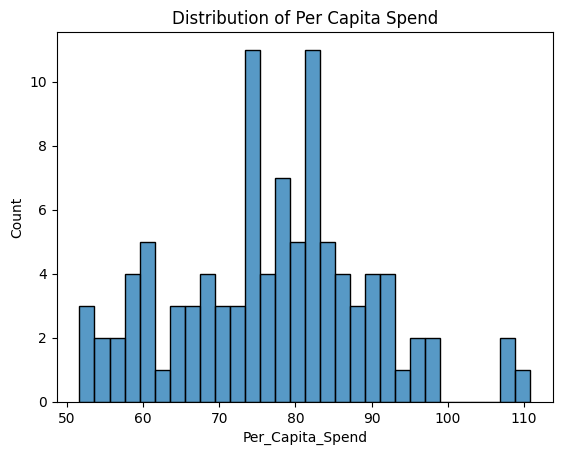

In [32]:
sns.histplot(x = 'Per_Capita_Spend', data = lobsterland_2, bins= 30)
plt.title('Distribution of Per Capita Spend')
plt.show()

This graph also shows a generall normally distrbuted trend, with two bimodal peaks around 75 and 85 dollars respectively. This graph shows more fluctuation throughout the normally distrbuted trends between each of the bins with a smaller count per bin. This graph may also suggest that the larger spend values are more likely to be outliers, as there are only 3 people who spent above 100 dollars, where it was less clear in the previous graph how far removed they would be from the majority of the data points. It gives greater certainty to the minimum values for entering the park to be just over 55 dollars.

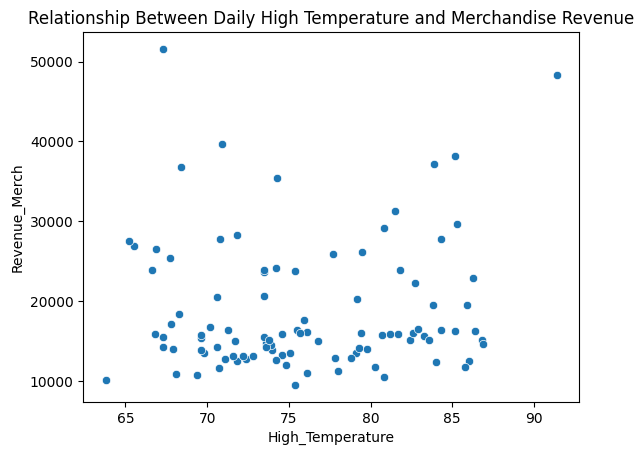

In [33]:
#N.
sns.scatterplot(x = 'High_Temperature', y = 'Revenue_Merch', data = lobsterland_2)
plt.title('Relationship Between Daily High Temperature and Merchandise Revenue')
plt.show()

There is no clear relationship between the Daily High Temperature and the Merchandise Revenue. There is likely no relationship between these variables as people are less inclined to buy additional clothing when the weather is hotter as they do not feel the need. Customers tend to behave according to their enviroment, and hot weather is less likely to influence them purchasing additional clothing. People may look to buy additional cold beverages or food on a hot day as a way to get relief from the heat instead.

/tmp/ipython-input-4262079929.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([day[:3] for day in lobsterland_2['Day_of_Week'].unique()])


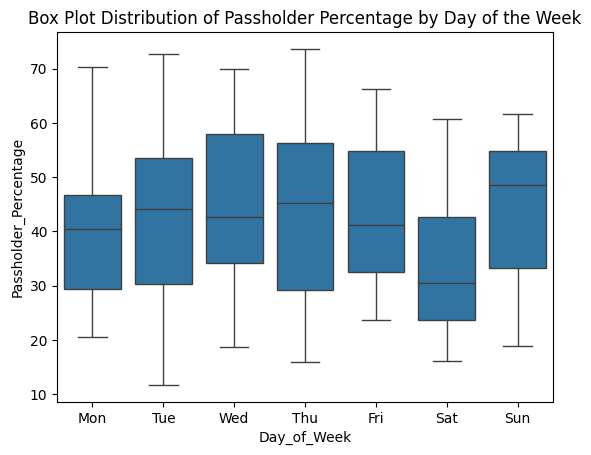

In [34]:
# O.
sns.boxplot(x = 'Day_of_Week', y = 'Passholder_Percentage', data = lobsterland_2)
plt.gca().set_xticklabels([day[:3] for day in lobsterland_2['Day_of_Week'].unique()])
plt.title('Box Plot Distribution of Passholder Percentage by Day of the Week')
plt.show()

The boxplot shows that the median percentage of passholders who attend lobsterland between Monday-Friday is relatively similar, between 40-45%. The ranges for Monday-Friday is between approximately 12-75%, showing that any given weekday can have significant variance, however the Inter Quartile Ranges all fall between 30-60% approximately. For the weekends, Saturdays median passholder percentage is the lowest of all days, at around 30%, with a smaller range of 18-60% approximately. The IQR for satirday is 25-42% approximately. On Sundays we see a higher passholder median percentage, at around 50%, with a range between 20-60% and an IQR of 35-55%. Sunday may be a slightly "passholder heavy" day because that is when locals who own season passes prefer to go, or because there are special events which fall on a Sunday. It may also be because with a season pass, you are able to attend multiple times for shorter periods of time, so they may repeat visit on sundays as a family outing, for example.

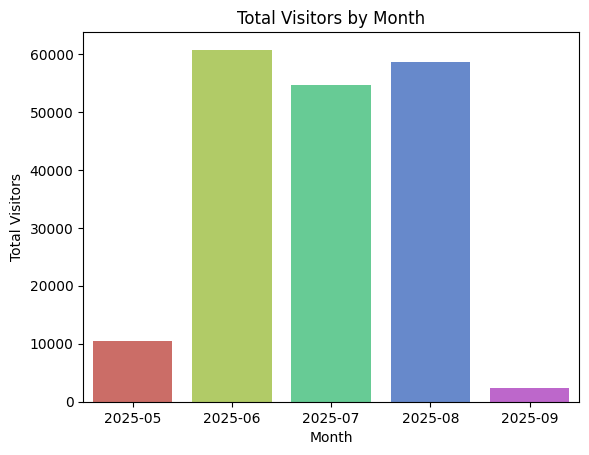

In [35]:
#P.
numeric_cols = lobsterland_2.select_dtypes(include=np.number).columns
monthly_summary = lobsterland_2.groupby(lobsterland_2['Date'].dt.to_period('M'))[numeric_cols].sum()

sns.barplot(x=monthly_summary.index.astype(str), y='Total_Visitors', data=monthly_summary, hue=monthly_summary.index.astype(str), palette='hls', legend=False)
plt.title('Total Visitors by Month')
plt.xlabel('Month')
plt.ylabel('Total Visitors')
plt.show()

The plot shows that the total number of visitors by month between June, July and August ranges between 55,000 and 60,000.  We are not able to gain much insight from May or September, as they were only open for a week and one day respectively. This is because lobsterland opened at the end of May (Memorial Day) and ended on the 1st of September (Labor Day). I would tell mananagement that the total vistors remains stable between June-August, with no significant difference between the months. We are unable to accurately compare May and September due to the difference in the days open within those months.

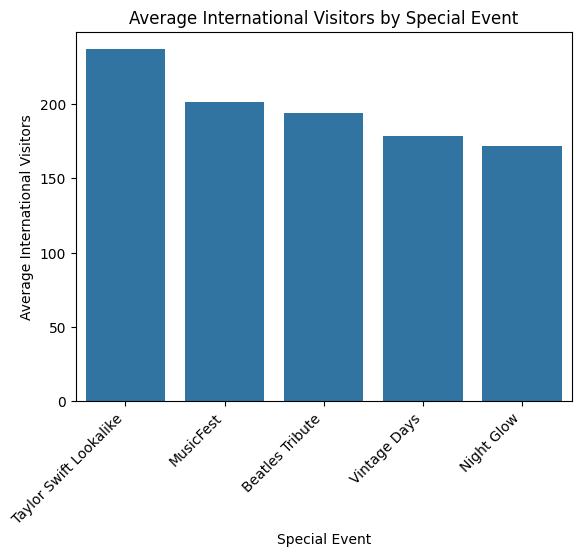

In [36]:
# Q.
lobsterland_no_none = lobsterland_2[lobsterland_2['Special_Events'] != 'None']
avg_int_visitors_by_event_all_tiers = lobsterland_no_none.groupby('Special_Events')['International_Visitors'].mean().sort_values(ascending=False)
sns.barplot(x=avg_int_visitors_by_event_all_tiers.index, y=avg_int_visitors_by_event_all_tiers.values, errorbar=None)
plt.title('Average International Visitors by Special Event')
plt.xlabel('Special Event')
plt.ylabel('Average International Visitors')
plt.xticks(rotation=45, ha='right')
plt.show()

What does your plot show, and why might it look this way? Why can we not conclude
causality from this relationship?

The plot shows that the average number of international visitors is highest for the Taylor Swift Lookalike concert at approximately 225, with the slowest being the Night Glow at approximately 175. This shows us that there is very little difference in the range average number of international visitors to special events. All of the other special events range between 180-200 international visitors on average.

We cannot conclude causality as we can not accurately determine the special events caused a difference in the number of international visitors. This is not possible as we are not able to control the other variables that may impact international visitors attending lobsterland, we do not know how many internationals attend lobsterland when there is not a special event, and finally, because the visual does not provide any numerical values to suggest stastical significance.

/tmp/ipython-input-2650200154.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([day[:3] for day in lobsterland_2['Day_of_Week'].unique()])


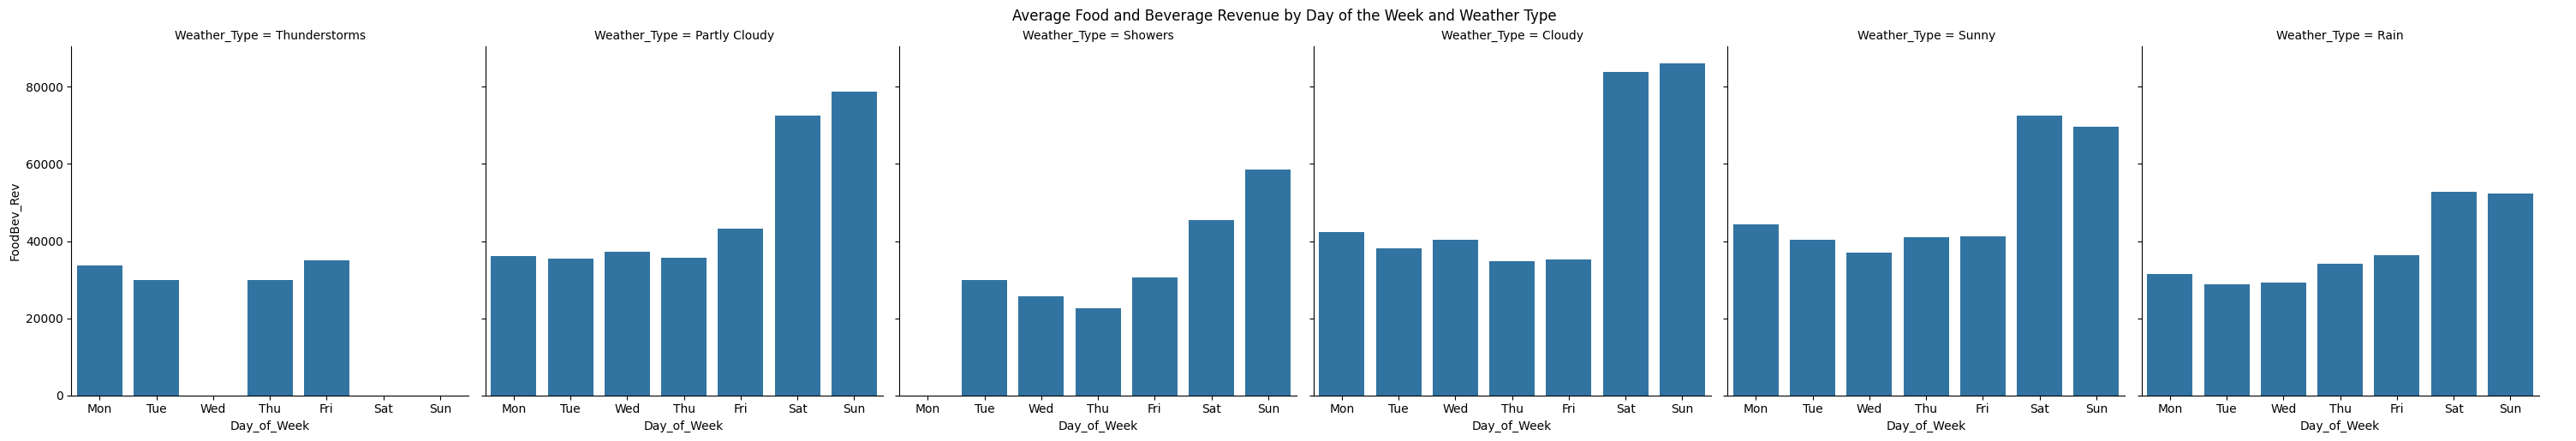

In [37]:
# R.
sns.catplot(x='Day_of_Week', y='FoodBev_Rev', col='Weather_Type', data=lobsterland_2, kind='bar', errorbar=None)
plt.gca().set_xticklabels([day[:3] for day in lobsterland_2['Day_of_Week'].unique()])
plt.suptitle('Average Food and Beverage Revenue by Day of the Week and Weather Type', y=1.02)
plt.show()


The most interesting factor is that regardless of weather, the weekend remains the highest days for food and beverage. Additionally, between partly cloudy, cloudy and sunny there is very little difference in the food and beverage revenue. On weekends when the weather is cloudy, the food and beverage revenue is at it highest, this may be because people like to attend lobsterland when the weather is slightly cooler/when the sun is not as hot and they can spend a longer time there.

An important limitation is that the graphs are spread out and it can be hard to directly compare between them, and accurately interepret the results. It would be easier if they were plotted on one plot, with each bar color coded for the weather pattern.This perhaps could be done in a clustered bar chart for visual analysis, or a summary table if you were more interested in the figures.

Another limitation is that by looking at the graphs, we can see four days where there is no food and beverage revenue data for that weather type - these fall under Thunderstroms and Showers. From the graphs, we cannot tell if this is because there were no sales on these days - perhaps because lobsterland was closed - or because the weather types did not fall on these days of the week. We would need to further explore the data to remove this limitation.



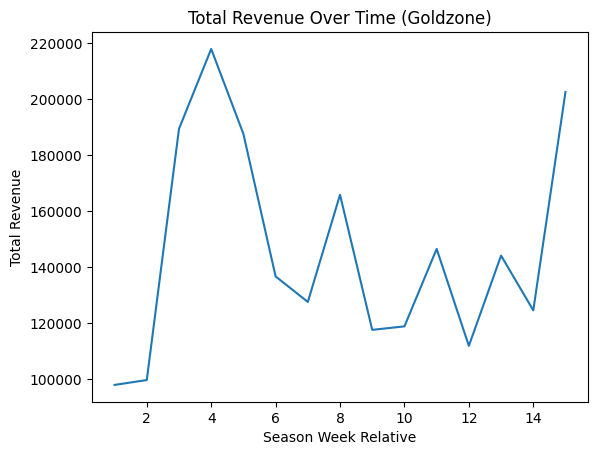

In [38]:
# S.
lobsterland_goldzone = lobsterland_2[lobsterland_2['Attraction_Tier'] == 1]

sns.lineplot(x='season_week_rel', y='Total_Revenue', data=lobsterland_goldzone, errorbar = None)
plt.title('Total Revenue Over Time (Goldzone)')
plt.xlabel('Season Week Relative')
plt.ylabel('Total Revenue')
plt.show()

The line plots starts low at 100,000, but then shows an increase from week 2 to week 4, where it peaks at 210,000, before declining significantly.Between week 5-14, we see some fluctuations in the revenue of goldzone is attributing to total revenue, but it generaly falls between 100,000 and 150,000. We see it increase for the final week back towards 200,000. There is no clear trend for this show period of time, but the data does allow for us to observe the changes between each week. These results show a strong revenue for the first month and final week, with volatile flucations between then.

To explain to an outside audience, we would be trying to demonstrate that impact that the goldzone attraction has on the total revenue. By looking at this we are able to see the weeks where the goldzone attraction is creating and or can be attributed to generating more total revenue, potentially suggesting when it is more popular and demanded by consumers.

**Wild Card: Metrics and "Quantified Self"**

A. I have chosen Calories Burned as my quanitifiable metric. This will be recorded by my Garmin Watch (Fenix 5x). The calories are defined as "Total Calories", which includes Active and Resting Calories.

B. Data (Total Calories Burned = Active + Resting)

The following data is taken directly from the Garmin Connect app. It counts the calories burned for the entirety of the day (24hr period).
9/15 - 3,018
9/16 - 3,799
9/17 - 3,237

C. I decided to track my total calories burned per day as my quantifiable metric. Since stopping full-time athletic training (Rowing), I have become more cautious of my daily activity and general health and wellness since I am no longer on a structured performance training plan. This includes ensuring that I still workout, opt for walking/cycling options where possible and monitoring my diet.  By tracking my total calories burned, I was able to see how my activities and and daily decisions impact my body in addition to my basal metabolic rate (Resting Calories Burned). I learned that the days where I am only able to do passive physical activity (e.g walking to and from class and lifting weights), I am still burning over 3,000 calories, where as on a day with walking, weights and a cardio workout I can increase that number significantly. On 9/16, I completed an additional 30' cardio workout compared to the other days that were only walking + lifting weights. I am definetely considering running this experiment for longer, and finding ways to keep that number consitently above 3,000, as well as seeing how my other hobbies (road cycling) will influence this number in addition to walking/weights.

I have really enjoyed this acitivity, and knowing that my garmin watch can enable me to track this data with ease and further enhanced my interest in tracking more 'lifetsyle metrics', rather than the 'performance metrics' I was used to in rowing.




